<div align="center">

# **Análisis del Dato**
## **Análisis del desequilibrio entre los precios de la vivienda en alquiler y los salarios de los jóvenes en España (2011–2024)**
### *Un enfoque provincial, explicativo y predictivo*

---

**Universidad Francisco de Vitoria · Madrid**  
**Grado en Business Analytics**  
**Trabajo de Fin de Grado de Business Analytics · Curso 2025–2026**

---

</div>

Este cuaderno es **reproducible** (se ejecuta de principio a fin sin errores) y constituye el soporte técnico de la sección 5, Análisis del Dato, de la memoria. Su estructura sigue las cinco etapas de la presentación de la asignatura, que coinciden con los criterios de la rúbrica de evaluación:

| Etapa de la presentación y criterio de la rúbrica | Sección del cuaderno |
|---|---|
| Marco teórico | §3 |
| Diseño de modelos (base frente a avanzado) | §4 |
| Métricas de evaluación | §5 |
| Visualización | §6 |
| Interpretación de resultados | §7 |

Las secciones §1 y §2 son preliminares (herramientas y preparación del modelado); el análisis exploratorio completo pertenece a la fase de Ingeniería del Dato y aquí no se repite.

**Pregunta de investigación:** ¿cuál es la magnitud del desequilibrio entre la accesibilidad del alquiler y los salarios de los jóvenes en España, cómo varía por provincia y en el tiempo, y qué escenarios se proyectan para 2025-2027?

### **¿De qué trata este trabajo?**

España atraviesa una crisis de accesibilidad a la vivienda en alquiler que afecta con especial dureza a la población joven en edad de emancipación. Este Trabajo Fin de Grado cuantifica y explica ese desequilibrio a escala provincial mediante la **tasa de esfuerzo** (alquiler sobre salario neto de la población joven), contrastada con el umbral del 30 % de asequibilidad, sobre las 48 provincias de régimen fiscal común entre 2011 y 2024, con una proyección de escenario para 2025-2027.

### **Pregunta central de investigación**

¿Cuál es la magnitud del desequilibrio entre el alquiler y el salario joven a escala provincial, cómo varía entre provincias y en el tiempo, y qué escenarios cabe proyectar? Se concreta en tres subpreguntas: qué determina el alquiler (explicación), cómo se agrupan las provincias según su (in)asequibilidad (tipologías) y hacia dónde evoluciona el esfuerzo (predicción).

### **¿Qué aporta el Análisis del Dato sobre la Ingeniería del Dato?**

La Ingeniería del Dato construyó y certificó el panel provincial a partir de fuentes oficiales. El Análisis del Dato, que desarrolla este cuaderno, no reconstruye ese panel: lo carga y, sobre él, cuantifica el desequilibrio, identifica los determinantes del alquiler comparando varios modelos, clasifica las provincias en tipologías y proyecta la tasa de esfuerzo.

### **Estructura de este notebook**

Tras configurar el entorno y cargar los datos heredados, el cuaderno sigue las cinco etapas del análisis: **(1)** marco teórico, **(2)** diseño y competición de modelos, **(3)** métricas de evaluación y robustez, **(4)** visualización y **(5)** interpretación de resultados.

---
## **1. Herramientas utilizadas**

El análisis se ha desarrollado íntegramente en Python 3, lenguaje que puede ejecutarse tanto en un entorno local como en Google Colab. Para garantizar la reproducibilidad de los resultados, tal y como exige la normativa del Trabajo Fin de Grado, se fija una semilla aleatoria (42) antes de cualquier procedimiento estocástico, de modo que el Random Forest, el Gradient Boosting y el K-Means devuelven siempre la misma solución. El cuaderno se ejecuta de principio a fin sin errores ni advertencias.

Cada librería cumple una función concreta dentro del trabajo. El manejo del panel se realiza con pandas y numpy; la regresión Ridge, el Random Forest, el Gradient Boosting, el K-Means y las métricas de error proceden de scikit-learn; el modelo de efectos fijos por mínimos cuadrados, el factor de inflación de la varianza (VIF), la prueba de estacionariedad de Dickey-Fuller y los modelos ARIMA se obtienen de statsmodels; y las representaciones gráficas se construyen con matplotlib y seaborn. El punto de partida son los conjuntos de datos depurados y certificados durante la fase de Ingeniería del Dato, que no se reconstruyen: se cargan y se analizan.

In [1]:
# Conexión con Google Drive (solo en Colab): da acceso a los paneles depurados en la Ingeniería del Dato.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass  # ejecución local (no Colab): los datos se cargan desde la ruta de respaldo de la celda siguiente


Mounted at /content/drive


In [2]:
# ════ SECCIÓN 1 · Configuración del entorno y carga de datos heredados ════
import numpy as np, pandas as pd, warnings
from pathlib import Path
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score, silhouette_score,
                             adjusted_rand_score)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# (Drive se conecta en la celda anterior cuando se ejecuta en Colab.)
# Reproducibilidad y salida limpia: se silencian los avisos no críticos (los de statsmodels
# al ajustar la serie corta de ARIMA ya se gestionan dentro del propio ajuste).
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
PAL=['#1f3b6f','#c0392b','#2e8b57','#e1a100','#7d3c98']

# Localización de los paneles limpios. En Colab viven en Google Drive, en la MISMA carpeta
# donde los exporta el notebook de Ingeniería del Dato; en local, en la estructura del TFG.
# Lectura DIRECTA desde la ruta confirmada (sin búsqueda ni glob; en Colab Drive ya está montado).
RUTA = Path('/content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven/data/clean')
if not RUTA.exists():                       # respaldo en ejecución local (no Colab)
    RUTA = Path('../../Entrega Ingeniería del Dato/Data/clean')
panel  = pd.read_csv(RUTA/'panel_TFG_alquiler_salario_48prov_2011_2024.csv')
edad   = pd.read_csv(RUTA/'panel_TFG_por_edad_2016obs.csv')
pobjov = pd.read_csv(RUTA/'panel_TFG_poblacion_joven_2011_2022.csv')
print('Datos cargados desde:', RUTA)
print(f'  panel principal {panel.shape} | por edad {edad.shape} | población joven {pobjov.shape}')

# Carpeta de salida para las figuras: LOCAL (no se escribe en Drive durante la ejecución,
# para no atascarse con el sistema de archivos de Drive). Las figuras también quedan embebidas.
FIG_DIR = (Path('/content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven')/'figuras'/'Análisis del Dato') if Path('/content/drive/MyDrive').is_dir() else Path('figuras')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Figuras se guardarán en:', FIG_DIR)

Datos cargados desde: /content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven/data/clean
  panel principal (672, 30) | por edad (2016, 11) | población joven (576, 3)
Figuras se guardarán en: /content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven/figuras/Análisis del Dato


**Conclusión de la sección 1.** Con el entorno configurado y los tres conjuntos de datos cargados, el cuaderno parte de una base depurada y reproducible. El panel principal sostiene el modelado; el panel por edad permitirá estudiar más adelante el gradiente de precariedad entre bandas de edad, y la serie de población joven servirá para dimensionar el impacto en la interpretación final.

---
## **2. Punto de partida y preparación para el modelado**

Esta sección no repite el análisis exploratorio, que pertenece a la Ingeniería del Dato y allí quedó cerrado. Su cometido es otro: delimitar el problema analítico, fijar la variable que se va a modelar y dejar preparada la matriz con la que trabajarán los modelos, recuperando de la fase anterior únicamente los dos resultados que condicionan esas decisiones.

### **2.1 El problema, la variable objetivo y los roles de las variables**

La pregunta de investigación se aborda desde tres ángulos complementarios, y cada uno reclama una familia de modelo distinta:

| Subpregunta | Modelo | Tipo |
|---|---|---|
| ¿Qué variables se asocian al alquiler, y por tanto al esfuerzo? | Ridge (base) frente a Random Forest y Gradient Boosting (avanzados) | Supervisado |
| ¿Cómo se agrupan las provincias según su (in)accesibilidad? | K-Means | No supervisado |
| ¿Hacia dónde evoluciona el esfuerzo? | ARIMA (escenario 2025-2027) | Series temporales |

La variable que se modela es el alquiler mediano provincial. La razón es empírica y se verifica en la sección siguiente: el esfuerzo se asocia mucho más con el alquiler (correlación en torno a 0,63) que con el salario (alrededor de -0,20), de manera que explicar el precio del alquiler concentra la parte más informativa de la variación del esfuerzo y evita la circularidad de modelar directamente el cociente alquiler/salario. Se descartan como predictores todas las variables que son el propio alquiler o se derivan de él (alquiler por metro cuadrado, superficie, alquiler real, tasa de esfuerzo y el indicador de umbral), para evitar la fuga de información.

Antes de avanzar conviene justificar por qué el problema central es de regresión y no de clasificación, pese a que la presentación de la asignatura ilustra la matriz de confusión y la curva ROC. Clasificar cada provincia-año como accesible o no accesible según el umbral del 30 % apenas tiene recorrido, como confirma la celda siguiente: casi todas las observaciones lo superan y muy pocas provincias cambian de situación a lo largo del periodo.

In [3]:
# Por qué el problema es de regresión y no de clasificación: con el umbral del 30% la clase es casi degenerada.
vc=panel.sobre_30.value_counts().rename({0:'accesible (≤30%)',1:'NO accesible (>30%)'})
print('Umbral 30% (sobre_30):'); print(vc.to_string())
print(f'  clase mayoritaria {panel.sobre_30.mean()*100:.1f}% y solo {(panel.groupby("cpro").sobre_30.nunique()==2).sum()}/48 provincias cambian -> clasificación degenerada')

Umbral 30% (sobre_30):
sobre_30
NO accesible (>30%)    644
accesible (≤30%)        28
  clase mayoritaria 95.8% y solo 4/48 provincias cambian -> clasificación degenerada


### **2.2 Dos resultados de la Ingeniería que condicionan el modelado**

La elección de las técnicas se apoya en dos hallazgos del análisis exploratorio ya realizado, que no se reproducen aquí en su totalidad. El primero es la fuerte colinealidad entre las variables salariales y la cuasi-identidad entre el alquiler y el alquiler por metro cuadrado, que recomiendan una regresión regularizada y la exclusión de esas variables. El segundo es el resultado de la prueba de Dickey-Fuller sobre la serie del esfuerzo, que la identifica como no estacionaria y obliga a diferenciarla antes de ajustar un modelo ARIMA. La celda siguiente reproduce, a modo de verificación puntual, tanto la asociación dominante del alquiler como ambos contrastes.

In [4]:
# Verificación puntual (no EDA completo): palanca dominante, leakage y estacionariedad
ce_alq = panel['tasa_esfuerzo'].corr(panel['alquiler_mediano'])
ce_sal = panel['tasa_esfuerzo'].corr(panel['neto_mes_26_35'])
print(f'Asociación del esfuerzo: corr(esfuerzo, alquiler) = {ce_alq:.2f} vs corr(esfuerzo, salario) = {ce_sal:.2f}. El alquiler presenta la asociación bivariante más estrecha con el KPI.')
print(f'Leakage: corr(alquiler_mediano, alquiler_m2) = {panel.alquiler_mediano.corr(panel.alquiler_m2):.3f}  -> se excluye como predictor')
serie = panel.groupby('año')['tasa_esfuerzo'].mean()
print(f'Estacionariedad (ADF): nivel p={adfuller(serie)[1]:.3f} (no estacionaria) | 1ª diferencia p={adfuller(serie.diff().dropna())[1]:.3f} (estacionaria) -> d=1')

Asociación del esfuerzo: corr(esfuerzo, alquiler) = 0.63 vs corr(esfuerzo, salario) = -0.20. El alquiler presenta la asociación bivariante más estrecha con el KPI.
Leakage: corr(alquiler_mediano, alquiler_m2) = 0.976  -> se excluye como predictor
Estacionariedad (ADF): nivel p=0.279 (no estacionaria) | 1ª diferencia p=0.005 (estacionaria) -> d=1


### **2.3 Matriz de modelado y estrategia de validación**

Los datos forman un panel de 48 provincias observadas durante 14 años, por lo que las observaciones no son independientes entre sí. Esto condiciona la validación: en lugar de una partición aleatoria, que mezclaría años y filtraría información del futuro hacia el pasado, se entrena con los años más antiguos y se evalúa en los posteriores. En la partición final se reserva 2024 como año de prueba, y se complementa con una validación de ventana expansiva entre 2018 y 2024. La matriz de diseño reúne los predictores admisibles junto con un efecto fijo de provincia, incorporado mediante variables indicadoras. Conviene precisar que esta validación es fuera de muestra en el eje temporal, pero está condicionada a las covariables observadas de cada año; no es, por tanto, una predicción ex ante del futuro. La regresión cumple un papel explicativo-predictivo y de comparación de modelos, mientras que la proyección estrictamente temporal se reserva al modelo ARIMA. La validación expansiva 2018-2024 es el esquema principal de evaluación; por ello 2024 actúa como la última ventana fuera de muestra de ese esquema y no como un conjunto de prueba ajeno por completo a la selección de hiperparámetros. Como comprobación de robustez, seleccionar el α de Ridge usando solo ventanas hasta 2023 devuelve el mismo valor, de modo que la conclusión no depende de incluir 2024 en la validación.

El tamaño muestral respalda cada familia de modelo, y se hace explícito porque condiciona qué es defendible. La **regresión supervisada** dispone de **624 observaciones** provincia-año para una decena de determinantes (más los efectos fijos de provincia); la regularización de Ridge gestiona además la colinealidad sin sobreajustar, de modo que la holgura es suficiente. El **agrupamiento K-Means** ordena las **48 provincias** sobre dos rasgos resumidos (nivel y tendencia del esfuerzo), una dimensión adecuada para una partición interpretable y validable con la silueta. La **serie temporal** es el caso más limitado: solo cuenta con **14 observaciones anuales**, por lo que se ajusta el modelo más parsimonioso posible (un paseo aleatorio con deriva), se elige su orden por prueba retrospectiva y no por criterios automáticos, y su salida se trata como un **escenario con intervalos**, no como una predicción puntual.

#### Tabla 1. Paneles de datos utilizados y su función en el análisis

| Panel | Observaciones | Cobertura | Función en el análisis |
|---|---|---|---|
| Panel principal | 672 (48 prov. × 14 años); 624 en el modelado | 30 variables, 2011–2024 | Modelado supervisado e inferencia sobre el alquiler |
| Panel por edad | 2.016 (× 3 bandas de edad) | 2011–2024 | Gradiente del esfuerzo entre bandas de edad |
| Población joven | 576 | Por provincia, hasta 2022 | Exposición territorial: jóvenes en provincias sobre el umbral |


In [5]:
# Matriz de modelado: variable objetivo (alquiler), determinantes depurados y efectos fijos de provincia.
d=panel.dropna(subset=['var_salario_pct']).copy()   # cae 2011 -> 624 obs
DET=['n_contratos','neto_mes_18_25','neto_mes_26_35','neto_mes_36_45','neto_mes_18_34',
     'paro_total','smi_mes','D_2021','neto_mes_26_35_lag1','paro_total_lag1','var_salario_pct']
prov=pd.get_dummies(d['provincia'],drop_first=True).astype(float); prov.index=d.index
y=d['alquiler_mediano']; yr=d['año']
def Xdet(): return d[DET].astype(float)
def Xfull(): X=pd.concat([d[DET].astype(float),prov],axis=1); X['año']=d['año'].values; return X
print(f'Matriz de modelado: {Xfull().shape[0]} obs × {Xfull().shape[1]} columnas (DET + {prov.shape[1]} indicadoras de provincia + año)')
print('Partición temporal: train ≤2023 / test 2024 ; CV expansiva 2018-2024.')

# Tabla 2 — Variables del modelado: el tipo se deriva de los datos; el rol documenta su función en el modelo
_unidad={'alquiler_mediano':'€/mes','n_contratos':'recuento','neto_mes_18_25':'€/mes','neto_mes_26_35':'€/mes','neto_mes_36_45':'€/mes','neto_mes_18_34':'€/mes','paro_total':'%','smi_mes':'€/mes','neto_mes_26_35_lag1':'€/mes','paro_total_lag1':'%','var_salario_pct':'%'}
_rol={'alquiler_mediano':'Variable objetivo','n_contratos':'Determinante: actividad del mercado de alquiler','neto_mes_18_25':'Determinante: salario neto 18-25 años','neto_mes_26_35':'Determinante: salario neto 26-35 años','neto_mes_36_45':'Determinante: salario neto 36-45 años','neto_mes_18_34':'Determinante: salario neto 18-34 años','paro_total':'Determinante: tasa de paro','smi_mes':'Determinante: salario mínimo interprofesional','D_2021':'Indicadora del efecto temporal de 2021','neto_mes_26_35_lag1':'Determinante rezagado (persistencia)','paro_total_lag1':'Determinante rezagado del paro','var_salario_pct':'Determinante: variación salarial interanual'}
def _tipo(col):
    s=d[col].dropna()
    if set(s.unique())<=set([0,1]): return 'Binaria (0/1)'
    return 'Numérica de recuento' if _unidad.get(col)=='recuento' else f'Numérica continua ({_unidad[col]})'
_rows=[(c,_tipo(c),_rol[c]) for c in ['alquiler_mediano']+DET]
_rows.append((f'Indicadoras de provincia ({prov.shape[1]})','Binarias (0/1)','Efectos fijos de provincia'))
_rows.append(('Tendencia anual','Numérica (año)','Control de tendencia temporal'))
tabla1=pd.DataFrame(_rows,columns=['Variable','Tipo','Rol en el modelo'])
print('Tabla 2. Variables del modelado (versión orientada a modelado). Fuente: elaboración propia')
print(tabla1.to_string(index=False))


Matriz de modelado: 624 obs × 59 columnas (DET + 47 indicadoras de provincia + año)
Partición temporal: train ≤2023 / test 2024 ; CV expansiva 2018-2024.
Tabla 2. Variables del modelado (versión orientada a modelado). Fuente: elaboración propia
                     Variable                      Tipo                                Rol en el modelo
             alquiler_mediano Numérica continua (€/mes)                               Variable objetivo
                  n_contratos      Numérica de recuento Determinante: actividad del mercado de alquiler
               neto_mes_18_25 Numérica continua (€/mes)           Determinante: salario neto 18-25 años
               neto_mes_26_35 Numérica continua (€/mes)           Determinante: salario neto 26-35 años
               neto_mes_36_45 Numérica continua (€/mes)           Determinante: salario neto 36-45 años
               neto_mes_18_34 Numérica continua (€/mes)           Determinante: salario neto 18-34 años
                   paro_tot

**Conclusión de la sección 2.** Con el problema delimitado, la variable objetivo fijada, los predictores depurados de fuga de información y la matriz de diseño construida (624 observaciones, tras descartar el año base 2011 por carecer de retardos), el cuaderno queda listo para plantear los modelos.

---
## **3. Marco teórico**

El desarrollo completo del marco teórico se encuentra en la memoria (apartado 2.4). Aquí conviene recordar la lógica que sostiene la elección de cada técnica, que en todos los casos responde a la naturaleza del dato antes que a su sofisticación.

El problema supervisado se plantea como una competición entre un modelo base y uno avanzado. Como base se emplea la regresión lineal con regularización de Ridge (Hoerl & Kennard, 1970): su penalización cuadrática estabiliza los coeficientes cuando los predictores están correlacionados, una situación frecuente entre las variables salariales del panel. Como modelos avanzados se recurre a dos conjuntos de árboles que captan relaciones no lineales e interacciones sin especificarlas de antemano: el Random Forest (Breiman, 2001), que promedia árboles entrenados sobre remuestras bootstrap (bagging), y el Gradient Boosting (Friedman, 2001), que los ajusta de forma secuencial corrigiendo el error del anterior (boosting). Uno y otro modelan el precio del alquiler dentro de la tradición de los precios hedónicos (Rosen, 1974), que explican el valor de un bien a partir de sus atributos y de su entorno.

La dimensión geográfica se aborda con el algoritmo de agrupamiento K-Means (MacQueen, 1967; Lloyd, 1982), una técnica estándar y computacionalmente eficiente, bien adaptada a las 48 provincias del estudio. La proyección temporal, por su parte, se apoya en la familia de modelos ARIMA (Box & Jenkins, 1976), cuyo empleo exige comprobar antes la estacionariedad de la serie mediante la prueba de Dickey-Fuller aumentada (Dickey & Fuller, 1979). Como se justifica más adelante, la brevedad de la serie obliga a tratar esta proyección como un escenario y no como una predicción puntual.

---
## **4. Diseño de modelos**

Esta sección plantea y ejecuta los tres modelos que responden a las subpreguntas de la investigación. Para el problema supervisado se construye un entorno de competición en el que un modelo base y uno avanzado se enfrentan sobre el mismo objetivo, tal y como exige la metodología de la asignatura. La lectura formal de las métricas, el análisis de robustez y la elección del modelo ganador se desarrollan en el apartado siguiente.

La Figura 1 resume en paralelo el flujo de cada modelo: la competición supervisada entre el modelo base (Ridge) y los avanzados (Random Forest y Gradient Boosting) sobre el mismo panel y la misma partición temporal, con el modelo ganador señalado y el bloque de inferencia por efectos fijos que lo complementa; a la derecha, los flujos del agrupamiento (K-Means) y de la serie temporal (ARIMA); y, debajo, los análisis complementarios.

### **Figura 1 — Flujo metodológico del Análisis del Dato**

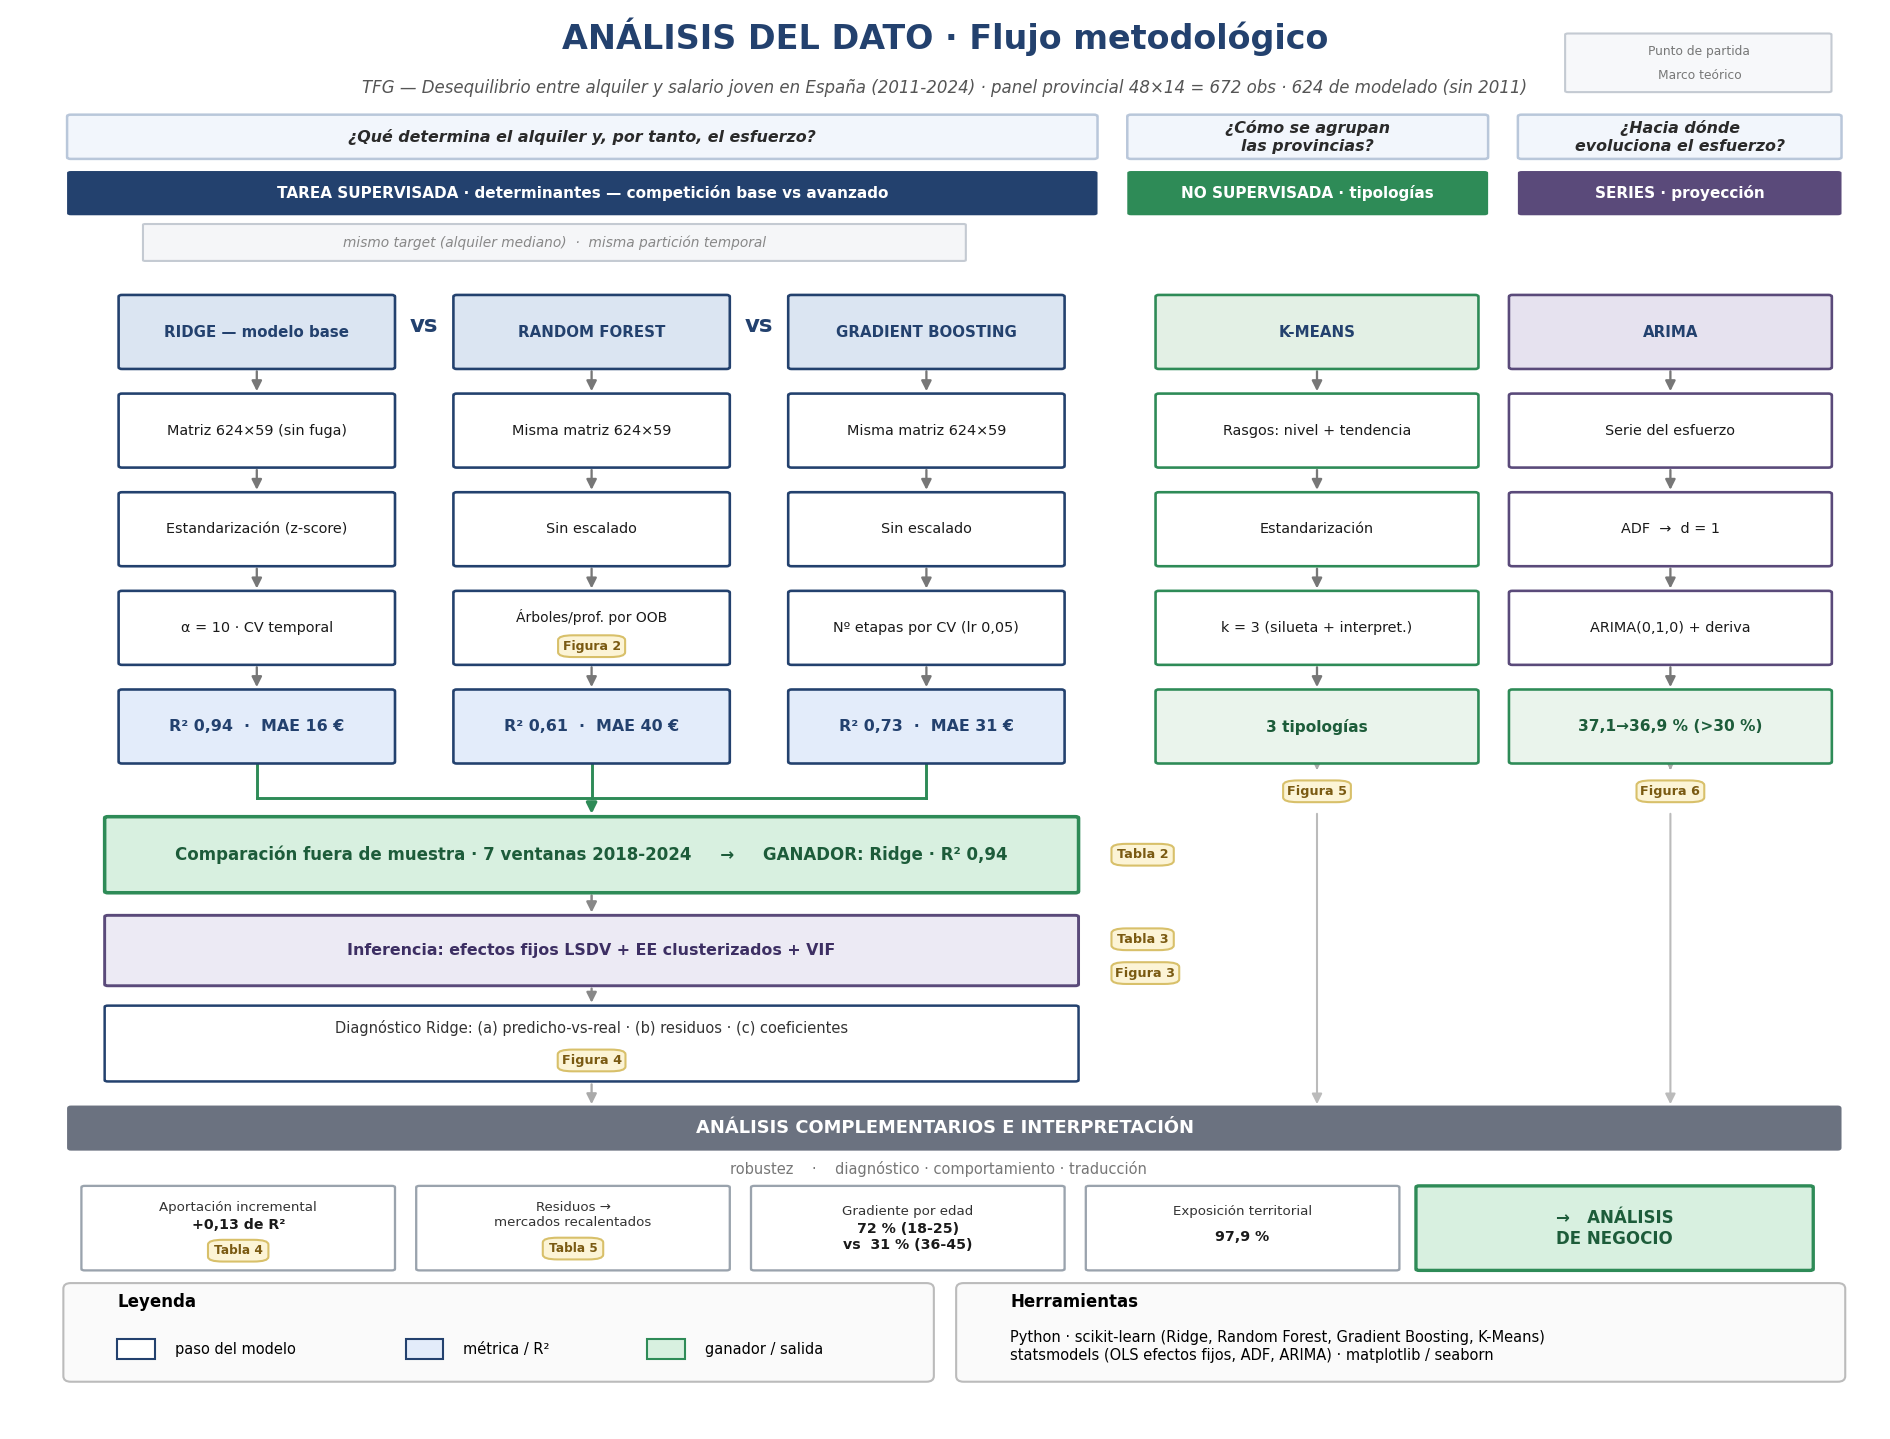

*El diagrama se genera con el script `generar_diagrama_flujo_analisis.py` (fuera del cuaderno, para que el código se centre en el análisis). Las etiquetas §x.y remiten a la sección del notebook.*

### **4.1 Modelo supervisado: regresión de los determinantes del alquiler**

El problema supervisado se resuelve enfrentando tres modelos sobre la misma variable objetivo y la misma partición temporal: un modelo base —una regresión lineal con regularización de Ridge, elegida por su interpretabilidad y por su robustez frente a la colinealidad— y dos modelos avanzados del paradigma de árboles, un Random Forest (agregación *bagging*) y un Gradient Boosting (*boosting*), capaces de recoger relaciones no lineales e interacciones. Los hiperparámetros no se fijan a mano: el parámetro de regularización de Ridge se valida temporalmente (resulta α = 10), la profundidad y la hoja mínima del Random Forest se escogen por su R² fuera de bolsa fijando el número de árboles con la curva OOB (Figura 2), y el número de etapas del Gradient Boosting se elige también por validación temporal. Así cada modelo compite con una configuración justa.

La comparación se realiza en dos encuadres del mismo problema y, en ambos, las métricas de la Tabla 3 son el promedio de una validación temporal de ventana expansiva —se entrena hasta cada año y se predice el siguiente, de 2018 a 2024, siete particiones fuera de muestra—, no de un único corte. En el encuadre de determinantes, el alquiler se predice a partir de variables estructurales del año en curso (salarios, paro, volumen de contratos y efecto de provincia); aquí el modelo base domina con holgura a los dos modelos de árboles (R² de 0,94 frente a 0,73 del Gradient Boosting y 0,61 del Random Forest). En el encuadre autorregresivo se añade el alquiler del año anterior y las diferencias prácticamente desaparecen (R² de 0,97 frente a 0,97 y 0,96). Ese contraste es la clave técnica: un conjunto de árboles no extrapola valores fuera del rango visto durante el entrenamiento, de modo que falla cuando debe proyectar la tendencia del alquiler a partir de los determinantes, pero compite cuando el rezago ya le aporta el nivel y no necesita extrapolar. El modelo lineal, en cambio, proyecta esa pendiente en los dos encuadres.

Aunque el encuadre autorregresivo obtiene un error algo menor, no se adopta como modelo explicativo principal: el alquiler rezagado absorbe gran parte de la persistencia del mercado y resta lectura a los determinantes estructurales. Por ello se interpreta como una referencia de persistencia, mientras que el modelo explicativo final es la regresión Ridge sobre los determinantes con efectos fijos de provincia. Conviene precisar que el análisis es explicativo-predictivo y no causal: al trabajar con datos observacionales, se habla de variables asociadas al alquiler, no de causas.

In [6]:
# ── Selección de hiperparámetros (no se fijan a mano) ──
# (a) Ridge: alpha por validación temporal (menor RMSE fuera de muestra)
ALPHAS=[0.001,0.01,0.1,0.3,1,3,10,30,100,300]
def _rmse_alpha(a, X, years=range(2017,2024)):
    e=[]
    for Y in years:
        tr=yr<=Y; te=yr==Y+1; sc=StandardScaler().fit(X[tr])
        m=Ridge(alpha=a).fit(sc.transform(X[tr]), y[tr]); e.append(mean_squared_error(y[te], m.predict(sc.transform(X[te])))**.5)
    return np.mean(e)
Xf=Xfull()
ridge_grid=pd.DataFrame({'alpha':ALPHAS,'RMSE_cv':[_rmse_alpha(a,Xf) for a in ALPHAS]})
best_alpha=float(ridge_grid.sort_values('RMSE_cv').iloc[0]['alpha'])
best_alpha_s24=float(pd.DataFrame({'a':ALPHAS,'r':[_rmse_alpha(a,Xf,range(2017,2023)) for a in ALPHAS]}).sort_values('r').iloc[0]['a'])
print('(a) Ridge — alpha por validación temporal (RMSE medio fuera de muestra):')
print(ridge_grid.round({'RMSE_cv':2}).to_string(index=False)); print(f'    alpha seleccionado = {best_alpha:g}  (excluyendo 2024 de la validación: {best_alpha_s24:g})')

# (b) Random Forest: profundidad y hoja mínima por R² fuera de bolsa (OOB)
grid=[]
for depth in [3,5,6,8,None]:
    for leaf in [1,3,5,10]:
        rf=RandomForestRegressor(n_estimators=200,max_depth=depth,min_samples_leaf=leaf,oob_score=True,bootstrap=True,random_state=42,n_jobs=1).fit(Xf,y)
        grid.append({'max_depth':depth,'min_samples_leaf':leaf,'OOB_R2':rf.oob_score_})
rf_grid=pd.DataFrame(grid).sort_values('OOB_R2',ascending=False)
_rd=rf_grid.iloc[0]['max_depth']; rf_depth=None if pd.isna(_rd) else int(_rd); rf_leaf=int(rf_grid.iloc[0]['min_samples_leaf'])
print('\n(b) Random Forest — mejores combinaciones por OOB:'); print(rf_grid.head(5).to_string(index=False))
print(f'    max_depth={rf_depth}, min_samples_leaf={rf_leaf}')
def make_ridge(): return Ridge(alpha=best_alpha)
def make_rf(): return RandomForestRegressor(n_estimators=300,max_depth=rf_depth,min_samples_leaf=rf_leaf,random_state=42,n_jobs=1)


(a) Ridge — alpha por validación temporal (RMSE medio fuera de muestra):
  alpha  RMSE_cv
  0.001    23.24
  0.010    23.19
  0.100    22.91
  0.300    22.57
  1.000    22.00
  3.000    21.49
 10.000    21.37
 30.000    22.46
100.000    27.32
300.000    38.52
    alpha seleccionado = 10  (excluyendo 2024 de la validación: 10)

(b) Random Forest — mejores combinaciones por OOB:
 max_depth  min_samples_leaf   OOB_R2
       NaN                 1 0.881057
       8.0                 1 0.861739
       NaN                 3 0.842202
       6.0                 1 0.837171
       8.0                 3 0.830787
    max_depth=None, min_samples_leaf=1


### **Figura 2 — Curva del R² fuera de bolsa del Random Forest**

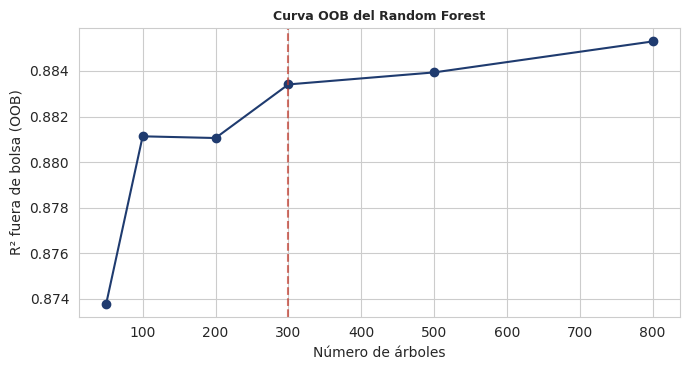

(c) El R² OOB mejora solo marginalmente a partir de 100 árboles; se adopta n_estimators=300 por parsimonia.


In [7]:
# (c) Nº de árboles: curva OOB con la profundidad/hoja seleccionadas
oob=pd.DataFrame([(n,RandomForestRegressor(n_estimators=n,max_depth=rf_depth,min_samples_leaf=rf_leaf,oob_score=True,random_state=42,n_jobs=1).fit(Xf,y).oob_score_) for n in [50,100,200,300,500,800]],columns=['n_estimators','OOB_R2'])
fig,ax=plt.subplots(figsize=(7,3.8)); ax.plot(oob.n_estimators,oob.OOB_R2,marker='o',color=PAL[0]); ax.axvline(300,ls='--',color=PAL[1],alpha=.7)
ax.set_xlabel('Número de árboles'); ax.set_ylabel('R² fuera de bolsa (OOB)')
ax.set_title('Curva OOB del Random Forest',fontweight='bold',fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR/'Analisis_Fig02_curva_OOB.png',dpi=150,bbox_inches='tight'); display(fig); plt.close(fig)
print('(c) El R² OOB mejora solo marginalmente a partir de 100 árboles; se adopta n_estimators=300 por parsimonia.')


In [8]:
# (d) Gradient Boosting (avanzado, boosting): nº de etapas por validación temporal
def _rmse_gb(n, X, years=range(2017,2024)):
    e=[]
    for Y in years:
        tr=yr<=Y; te=yr==Y+1
        g=GradientBoostingRegressor(n_estimators=n,learning_rate=0.05,max_depth=3,random_state=42).fit(X[tr],y[tr])
        e.append(mean_squared_error(y[te],g.predict(X[te]))**.5)
    return np.mean(e)
GBN=[100,200,300,500]
gb_grid=pd.DataFrame({'n_estimators':GBN,'RMSE_cv':[_rmse_gb(n,Xf) for n in GBN]})
best_gbn=int(gb_grid.sort_values('RMSE_cv').iloc[0]['n_estimators'])
print('\n(d) Gradient Boosting — nº de etapas por validación temporal (RMSE fuera de muestra):')
print(gb_grid.round({'RMSE_cv':2}).to_string(index=False)); print(f'    n_estimators={best_gbn} (learning_rate=0.05, max_depth=3)')
def make_gb(): return GradientBoostingRegressor(n_estimators=best_gbn,learning_rate=0.05,max_depth=3,random_state=42)



(d) Gradient Boosting — nº de etapas por validación temporal (RMSE fuera de muestra):
 n_estimators  RMSE_cv
          100    52.25
          200    47.61
          300    45.17
          500    42.78
    n_estimators=500 (learning_rate=0.05, max_depth=3)


In [9]:
# Competición base vs avanzados por validación temporal de ventana expansiva (2018-2024) -> Tabla 3.
def cv_temporal(Xb, scale=True, model='ridge', extra=None):
    out={'MAE':[],'RMSE':[],'MAPE':[],'R2':[],'R2_in':[]}
    for Y in range(2017,2024):
        tr=yr<=Y; te=yr==Y+1
        X=Xb() if extra is None else extra()
        Xtr,Xte=X[tr],X[te]
        if scale: sc=StandardScaler().fit(Xtr); Xtr,Xte=sc.transform(Xtr),sc.transform(Xte)
        m={'ridge':make_ridge,'rf':make_rf,'gb':make_gb}[model]().fit(Xtr,y[tr])
        p=m.predict(Xte)
        out['MAE'].append(mean_absolute_error(y[te],p)); out['RMSE'].append(mean_squared_error(y[te],p)**.5)
        out['MAPE'].append(mean_absolute_percentage_error(y[te],p)*100); out['R2'].append(r2_score(y[te],p))
        out['R2_in'].append(r2_score(y[tr],m.predict(Xtr)))   # R2 dentro de muestra (entrenamiento)
    return {k:np.mean(v) for k,v in out.items()}
def Xa2(): X=Xfull().copy(); X['alq_lag1']=d['alquiler_mediano_lag1'].values; return X
rows=[]
for lab,Xb,mdl,extra in [('A1 Determinantes · Ridge (base)',Xfull,'ridge',None),
                         ('A1 Determinantes · Random Forest',Xfull,'rf',None),
                         ('A1 Determinantes · Gradient Boosting',Xfull,'gb',None),
                         ('A2 Autorregresivo · Ridge (base)',Xa2,'ridge',Xa2),
                         ('A2 Autorregresivo · Random Forest',Xa2,'rf',Xa2),
                         ('A2 Autorregresivo · Gradient Boosting',Xa2,'gb',Xa2)]:
    r=cv_temporal(Xb,scale=(mdl=='ridge'),model=mdl,extra=extra); r['Modelo']=lab; rows.append(r)
tab2=pd.DataFrame(rows).rename(columns={'R2_in':'R² entren.','R2':'R² fuera de muestra'})
tab2=tab2[['Modelo','MAE','RMSE','MAPE','R² entren.','R² fuera de muestra']].round({'MAE':1,'RMSE':1,'MAPE':2,'R² entren.':3,'R² fuera de muestra':3})
print('Tabla 3. Comparación de los modelos de regresión: R² dentro y fuera de muestra (validación temporal). Fuente: elaboración propia')
print(tab2.to_string(index=False))

Tabla 3. Comparación de los modelos de regresión: R² dentro y fuera de muestra (validación temporal). Fuente: elaboración propia
                               Modelo  MAE  RMSE  MAPE  R² entren.  R² fuera de muestra
      A1 Determinantes · Ridge (base) 16.1  21.4  3.53       0.980                0.937
     A1 Determinantes · Random Forest 40.2  52.9  8.74       0.989                0.609
 A1 Determinantes · Gradient Boosting 30.7  42.8  6.58       0.993                0.732
     A2 Autorregresivo · Ridge (base) 11.3  14.4  2.52       0.990                0.970
    A2 Autorregresivo · Random Forest 12.1  16.2  2.60       0.998                0.959
A2 Autorregresivo · Gradient Boosting 11.1  14.6  2.42       0.999                0.968


La competición anterior selecciona el mejor modelo predictivo, pero no autoriza por sí sola a interpretar coeficientes. Para responder a *qué* se asocia con el alquiler con inferencia válida, se estima en paralelo un modelo de efectos fijos provinciales (LSDV) —indicadoras de provincia más una tendencia anual— por mínimos cuadrados con errores estándar clusterizados por provincia, robustos a la autocorrelación intraprovincial. El diagnóstico de colinealidad —la matriz de correlación de la Figura 3 y los VIF de la Tabla 4— explica por qué la regularización es necesaria y por qué los coeficientes deben leerse en bloque y no uno a uno: las distintas medidas de salario están extremadamente correlacionadas entre sí (correlaciones próximas a la unidad en la Figura 3 y VIF del orden de 10³ en la Tabla 4), de modo que sus coeficientes individuales no son identificables por separado. Con esa cautela, el determinante que se mantiene significativo incluso bajo la especificación más exigente de efectos fijos de dos vías (provincia y año) es el volumen de contratos; el salario mínimo es significativo en la especificación con tendencia anual, pero, como toda variable nacional, queda absorbido por los efectos de año por construcción y por eso no figura en esa segunda especificación. Conviene señalar, por último, que en los modelos de conjunto la interpretabilidad suele apoyarse en técnicas como los valores SHAP; aquí no resultan necesarios, porque el modelo ganador es lineal y sus coeficientes estandarizados (Figura 4, panel c), junto con la inferencia de efectos fijos (Tabla 4), cumplen directamente esa función explicativa.

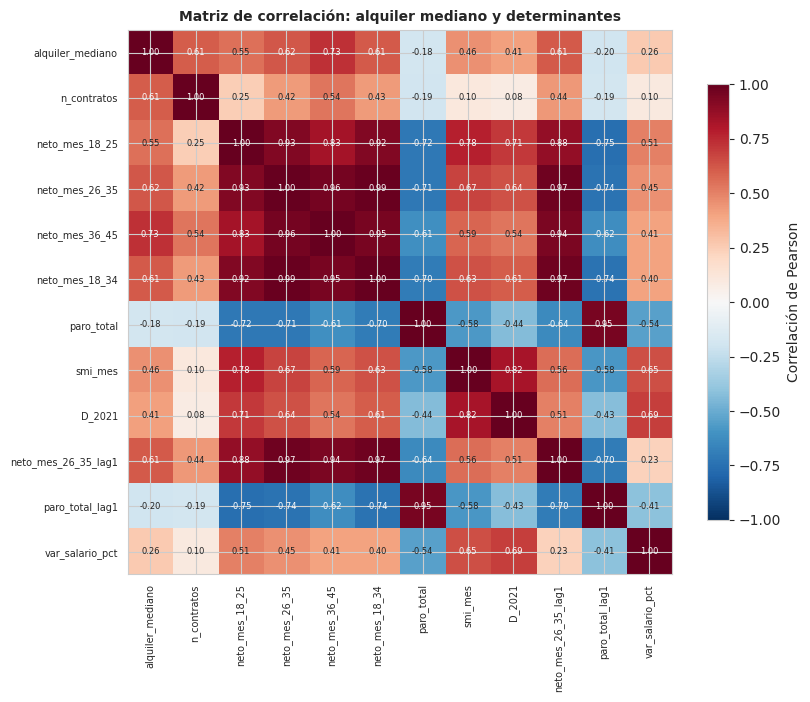

Correlación alquiler-determinantes (n = 624 obs). Máx. |corr| fuera de la diagonal entre salarios: 0.988


In [10]:
# Figura 3 — Matriz de correlación de la variable objetivo y los determinantes (diagnóstico de colinealidad)
cols=['alquiler_mediano']+DET
cm=d[cols].astype(float).corr()
fig,ax=plt.subplots(figsize=(8.5,7))
im=ax.imshow(cm.values,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=90,fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols,fontsize=7)
for i in range(len(cols)):
    for j in range(len(cols)):
        v=cm.values[i,j]; ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=6,color='white' if abs(v)>0.6 else '#222')
fig.colorbar(im,ax=ax,shrink=0.8,label='Correlación de Pearson')
ax.set_title('Matriz de correlación: alquiler mediano y determinantes',fontweight='bold',fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/'Analisis_Fig03_correlaciones.png',dpi=150,bbox_inches='tight'); display(fig); plt.close(fig)
print('Correlación alquiler-determinantes (n =', len(d), 'obs). Máx. |corr| fuera de la diagonal entre salarios:', round(cm.loc[[c for c in DET if c.startswith('neto')],[c for c in DET if c.startswith('neto')]].where(lambda x: x<1).abs().max().max(),3))

In [11]:
# ── Inferencia sobre los determinantes: efectos fijos provinciales (LSDV) con EE clusterizados ──
# Ridge/RF/GB se usan para PREDECIR; para INTERPRETAR qué determinantes mueven el alquiler usamos un
# modelo de efectos fijos (LSDV: dummies de provincia + tendencia anual) estimado por OLS con errores
# estándar robustos clusterizados por provincia (Arellano), válidos ante autocorrelación intra-provincia.
Xfe=sm.add_constant(Xfull().astype(float))
fe=sm.OLS(y, Xfe).fit(cov_type='cluster', cov_kwds={'groups': d['cpro']})
det_tab=pd.DataFrame({'coef':fe.params[DET],'EE_cluster':fe.bse[DET],'t':fe.tvalues[DET],'p':fe.pvalues[DET]})
# n_contratos tiene coef y EE diminutos en unidades crudas; se expresa por cada 1.000 contratos para legibilidad (t y p no cambian).
det_tab.loc['n_contratos',['coef','EE_cluster']]*=1000
det_tab=det_tab.rename(index={'n_contratos':'n_contratos (por 1.000)'})
print('Tabla 4. Determinantes del alquiler — efectos fijos provinciales (LSDV), EE clusterizados por provincia. Fuente: elaboración propia')
print(det_tab.round(3).to_string())
print(f'R2 (con efectos fijos): {fe.rsquared:.3f} | nº de provincias (clusters): {d.cpro.nunique()} | obs: {int(fe.nobs)}')

# Colinealidad entre determinantes (VIF): justifica la regularización y obliga a leer los coeficientes con cautela
Xv=sm.add_constant(Xdet().astype(float))
vif=pd.Series({c:variance_inflation_factor(Xv.values,j) for j,c in enumerate(Xv.columns) if c!='const'}).sort_values(ascending=False)
print('\nDiagnóstico de colinealidad — VIF de los determinantes (>10 = colinealidad alta):')
print(vif.round(1).to_string())

# Robustez: efectos fijos de DOS vías (provincia + año en dummies). Las variables NACIONALES (SMI) y el
# salto puntual D_2021 quedan absorbidos por los efectos de año por construcción; por eso la especificación
# principal usa una tendencia anual en lugar de dummies de año.
yd=pd.get_dummies(d['año'],prefix='y',drop_first=True).astype(float); yd.index=d.index
prov_det=[c for c in DET if c not in ('smi_mes','D_2021')]
Xtw=sm.add_constant(pd.concat([d[prov_det].astype(float),prov,yd],axis=1))
tw=sm.OLS(y,Xtw).fit(cov_type='cluster',cov_kwds={'groups':d['cpro']})
print('\nRobustez — efectos fijos de DOS vías (provincia + año). Determinantes provinciales:')
tw_tab=pd.DataFrame({'coef':tw.params[prov_det],'EE_cluster':tw.bse[prov_det],'p':tw.pvalues[prov_det]})
tw_tab.loc['n_contratos',['coef','EE_cluster']]*=1000
tw_tab=tw_tab.rename(index={'n_contratos':'n_contratos (por 1.000)'})
print(tw_tab.round(3).to_string())
print(f'(SMI y D_2021 omitidos: nacionales/temporales, absorbidos por los efectos de año. R2 dos vías: {tw.rsquared:.3f})')

Tabla 4. Determinantes del alquiler — efectos fijos provinciales (LSDV), EE clusterizados por provincia. Fuente: elaboración propia
                           coef  EE_cluster      t      p
n_contratos (por 1.000)   0.563       0.144  3.907  0.000
neto_mes_18_25            0.124       0.063  1.967  0.049
neto_mes_26_35           -0.028       0.237 -0.119  0.905
neto_mes_36_45           -0.075       0.104 -0.723  0.469
neto_mes_18_34           -0.096       0.197 -0.488  0.625
paro_total                0.398       0.502  0.793  0.428
smi_mes                   0.130       0.026  5.077  0.000
D_2021                   13.466       6.480  2.078  0.038
neto_mes_26_35_lag1       0.256       0.304  0.842  0.400
paro_total_lag1          -0.068       0.520 -0.130  0.897
var_salario_pct           1.431       2.831  0.506  0.613
R2 (con efectos fijos): 0.975 | nº de provincias (clusters): 48 | obs: 624

Diagnóstico de colinealidad — VIF de los determinantes (>10 = colinealidad alta):
neto_mes_26_35

### **4.2 Modelo no supervisado: tipologías provinciales con K-Means**

La dimensión geográfica se aborda agrupando las 48 provincias según dos rasgos que resumen su comportamiento a lo largo del periodo: el nivel medio de la tasa de esfuerzo y su tendencia anual. Ambas variables se estandarizan para que ninguna domine por su escala. El número de grupos se decide combinando el coeficiente de silueta con la interpretabilidad. La silueta es ligeramente superior con dos grupos (0,51 frente a 0,49 con tres), pero esa partición se limita a separar provincias caras y baratas; se opta por tres grupos, cuya silueta es casi idéntica y que aportan un valor interpretativo claramente mayor. Para cada tipología, la salida muestra su tamaño, su nivel medio de esfuerzo, su tendencia y algunas provincias representativas.

In [12]:
# K-Means: tipologías provinciales según nivel y tendencia del esfuerzo; k por silueta + interpretabilidad + robustez (ARI).
prof=panel.groupby('cpro').apply(lambda g: pd.Series({'nivel':g['tasa_esfuerzo'].mean(),
     'tendencia':np.polyfit(g['año'],g['tasa_esfuerzo'],1)[0]}), include_groups=False)
prov_names=panel.groupby('cpro')['provincia'].first()
Z=StandardScaler().fit_transform(prof.values)
sil={k:silhouette_score(Z,KMeans(k,n_init=10,random_state=42).fit_predict(Z)) for k in range(2,6)}
print('Silueta por k:', {k:round(v,3) for k,v in sil.items()})
# La silueta es máxima en k=2, pero por escaso margen; se adopta k=3 por interpretabilidad de negocio
# (tres tipologías accionables: aguda / intermedia / contenida) y se verifica su robustez con un método jerárquico.
_km3=KMeans(3,n_init=10,random_state=42).fit_predict(Z); _agg=AgglomerativeClustering(n_clusters=3).fit_predict(Z)
print(f'k* por silueta = {max(sil,key=sil.get)} (margen silueta k2-k3 = {sil[2]-sil[3]:+.3f}); se adopta k=3 por interpretabilidad de negocio.')
print(f'Robustez de k=3: concordancia K-Means vs jerárquico (ARI) = {adjusted_rand_score(_km3,_agg):.2f}')
K=3
prof['cluster']=KMeans(K,n_init=10,random_state=42).fit_predict(Z)
print(f'\nTipologías (k={K}):')
for c in range(K):
    sub=prof[prof.cluster==c]
    print(f'  Clúster {c}: n={len(sub)} | nivel {sub.nivel.mean():.1f}% | tendencia {sub.tendencia.mean():+.2f} p.p./año | ej.: {", ".join(prov_names.loc[sub.index].head(4))}')

Silueta por k: {2: np.float64(0.514), 3: np.float64(0.486), 4: np.float64(0.484), 5: np.float64(0.351)}
k* por silueta = 2 (margen silueta k2-k3 = +0.028); se adopta k=3 por interpretabilidad de negocio.
Robustez de k=3: concordancia K-Means vs jerárquico (ARI) = 0.86

Tipologías (k=3):
  Clúster 0: n=10 | nivel 45.9% | tendencia +0.25 p.p./año | ej.: Balears, Illes, Barcelona, Cádiz, Madrid
  Clúster 1: n=32 | nivel 35.0% | tendencia -0.13 p.p./año | ej.: Albacete, Alicante/Alacant, Ávila, Badajoz
  Clúster 2: n=6 | nivel 43.7% | tendencia -0.43 p.p./año | ej.: Almería, Córdoba, Cuenca, Huelva


### **4.3 Series temporales: proyección del esfuerzo con ARIMA**

La trayectoria futura de la tasa de esfuerzo se estima sobre la serie nacional agregada. Al tratarse de datos anuales no procede ningún componente estacional. Como la serie es corta, el orden del modelo se elige por su capacidad predictiva en una prueba retrospectiva sobre los últimos años, y no por criterios automáticos: el modelo más parsimonioso, un paseo aleatorio con deriva, es el que comete menor error. La proyección para el trienio 2025-2027 se acompaña de sus intervalos de confianza y se interpreta como un escenario, no como una predicción exacta. Se opta por un ARIMA univariante y no por una variante con regresores exógenos (SARIMAX): incorporar variables externas obligaría a proyectarlas también hacia 2025-2027, acumulando incertidumbre sobre una serie ya de por sí corta, de modo que el escenario parsimonioso es más honesto con la información disponible.

In [13]:
# ARIMA sobre la serie nacional del esfuerzo: orden elegido por backtest y escenario 2025-2027 con intervalos.
s=panel.groupby('año')['tasa_esfuerzo'].mean(); s.index=pd.period_range('2011',periods=len(s),freq='Y')
# La serie es muy corta (14 puntos): los avisos de optimización/convergencia de ARIMA son
# esperables y se suprimen SOLO dentro del ajuste, manteniendo el modo error en el resto.
def _fit_arima(serie, order, trend=None):
    with warnings.catch_warnings():
        # Ruido típico de la estimación MLE de ARIMA en series cortas (no afecta al escenario)
        for _c in (ConvergenceWarning, ValueWarning, UserWarning):
            warnings.filterwarnings('ignore', category=_c)
        return ARIMA(serie, order=order, trend=trend).fit()
# Backtest one-step de los últimos 4 años para elegir el orden más parsimonioso
def bt(order, trend=None):
    e=[abs(_fit_arima(s.iloc[:cut], order, trend).forecast(1).iloc[0]-s.iloc[cut]) for cut in range(len(s)-4,len(s))]
    return float(np.mean(e))
bt_res={f'{o}{("+t" if t else "")}': round(bt(o,t),2) for o,t in [((0,1,0),'t'),((1,1,0),None),((1,1,1),None)]}
print('Backtest MAE (p.p.):', bt_res)
m=_fit_arima(s,(0,1,0),'t')
fc=m.get_forecast(3); ci=fc.conf_int(alpha=0.2)
print('\nEscenario 2025-2027 (paseo aleatorio con deriva):')
for a,mu,(lo,hi) in zip([2025,2026,2027],fc.predicted_mean,ci.values):
    print(f'  {a}: {mu:.1f}%  (IC80% {lo:.1f}–{hi:.1f})')

Backtest MAE (p.p.): {'(0, 1, 0)+t': 0.92, '(1, 1, 0)': 1.19, '(1, 1, 1)': 1.37}

Escenario 2025-2027 (paseo aleatorio con deriva):
  2025: 37.1%  (IC80% 36.0–38.2)
  2026: 37.0%  (IC80% 35.4–38.5)
  2027: 36.9%  (IC80% 35.0–38.8)


**Conclusión de la sección 4.** La competición sobre las mismas variables y la misma partición temporal selecciona la regresión Ridge como modelo explicativo, porque generaliza mejor que los árboles en un panel pequeño y con tendencia; el bloque de inferencia con efectos fijos provinciales acota la lectura de los determinantes, el K-Means ordena el territorio en tres tipologías y el ARIMA proyecta el escenario del esfuerzo. Las tres salidas alimentan la interpretación posterior.

---
## **5. Métricas de evaluación y robustez**

La adecuación de los modelos se mide con medidas complementarias adaptadas a cada tipo de problema. En los modelos predictivos, regresión y serie temporal, el error se evalúa siempre fuera de muestra: el error absoluto medio (MAE) recoge el error típico en las unidades de la variable, es decir, en euros de alquiler; la raíz del error cuadrático medio (RMSE) penaliza con mayor severidad los errores grandes; el error porcentual absoluto medio (MAPE) relativiza el error respecto al valor real; y el coeficiente de determinación (R²) indica qué proporción de la variabilidad del alquiler queda explicada. La proyección temporal se valora, además, con el error de una prueba retrospectiva. El agrupamiento, que no es un problema predictivo, se evalúa con el coeficiente de silueta, un índice de validez interna que mide la cohesión dentro de cada grupo y la separación entre grupos. Todas estas medidas se aplicaron al comparar los modelos en el apartado anterior, y el criterio de selección es el **rendimiento fuera de muestra**: se elige el modelo con mayor R² y menor error. La regresión **Ridge** es la ganadora —R² de **0,94** frente a **0,73** del Gradient Boosting y **0,61** del Random Forest, y el menor MAE y RMSE de los tres (Tabla 3)—, además de ser la única que extrapola la tendencia del alquiler en lugar de quedar topada por el rango de entrenamiento.

A esa selección conviene añadirle un análisis de robustez. Como el modelo incorpora un efecto fijo de provincia, cabe preguntarse si el acierto del modelo explicativo procede de los determinantes o simplemente de la identidad de cada territorio, esto es, del hecho de que el alquiler sea caro allí donde siempre lo ha sido. Para despejarlo se comparan tres ajustes anidados que aíslan la aportación incremental de los determinantes: uno con la provincia y el año únicamente, otro con los determinantes únicamente y un tercero con ambos a la vez (Tabla 5).

In [14]:
# Aportación incremental: capacidad explicativa con y sin determinantes (R² fuera de muestra, CV temporal)
def cv_R2(builder):
    r=[]
    for Y in range(2017,2024):
        tr=yr<=Y; te=yr==Y+1; X=builder()
        sc=StandardScaler().fit(X[tr]); m=make_ridge().fit(sc.transform(X[tr]),y[tr]); r.append(r2_score(y[te],m.predict(sc.transform(X[te]))))
    return np.mean(r)
def Xprov(): X=prov.copy(); X['año']=d['año'].values; return X
r_prov, r_det, r_full = cv_R2(Xprov), cv_R2(Xdet), cv_R2(Xfull)
print('Tabla 5. Aportación incremental de los determinantes sobre la identidad provincial (R² fuera de muestra). Fuente: elaboración propia')
print(f'  solo efectos fijos de provincia + tendencia anual : {r_prov:.3f}')
print(f'  solo determinantes               : {r_det:.3f}')
print(f'  ambos (modelo final)             : {r_full:.3f}')
print(f'  -> aporte incremental de los determinantes: {r_full-r_prov:+.3f}')
# Ganador: Ridge (base) — se justifica por menor error fuera de muestra y porque RF no extrapola la tendencia
print(f'\nLa identidad provincial explica buena parte del nivel, pero los determinantes añaden {r_full-r_prov:+.2f} de R²: el modelo no es una mera identidad de provincia.')

Tabla 5. Aportación incremental de los determinantes sobre la identidad provincial (R² fuera de muestra). Fuente: elaboración propia
  solo efectos fijos de provincia + tendencia anual : 0.805
  solo determinantes               : 0.636
  ambos (modelo final)             : 0.937
  -> aporte incremental de los determinantes: +0.132

La identidad provincial explica buena parte del nivel, pero los determinantes añaden +0.13 de R²: el modelo no es una mera identidad de provincia.


El resultado despeja la duda. La identidad provincial explica una parte importante del nivel del alquiler, como era esperable en un mercado tan segmentado territorialmente, pero los determinantes aportan una mejora real, de unos trece puntos de R² sobre la provincia sola. El modelo, por tanto, no se limita a reconocer las provincias caras: captura además la dinámica con la que el alquiler se asocia al salario, al paro y al volumen de mercado dentro de cada territorio.

---
## **6. Visualización**

La presentación de la asignatura señala la visualización como una pieza central del análisis. Las figuras que siguen documentan tanto el rendimiento de los modelos como los patrones que revelan, y cada una se comenta en el texto. La Figura 4 reúne el diagnóstico del modelo seleccionado en tres paneles: (a) el alquiler predicho frente al observado en el año de prueba, (b) los residuos del modelo y (c) las variables ordenadas según su importancia. Las dos figuras siguientes resumen el agrupamiento provincial (Figura 5) y el escenario temporal del esfuerzo (Figura 6).

Todas las figuras de esta sección son de elaboración propia a partir de los paneles depurados en la Ingeniería del Dato.

### **Figura 4 — Diagnóstico del modelo Ridge: (a) predicho frente a observado, (b) residuos, (c) coeficientes estandarizados**

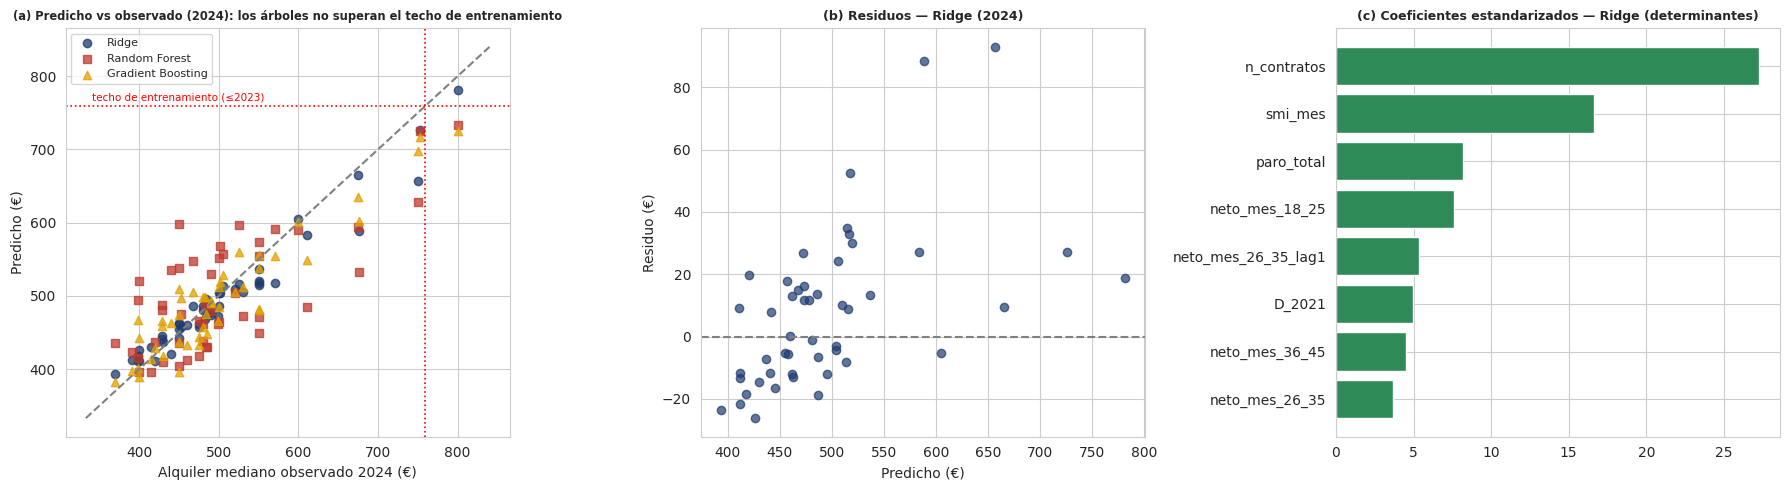

In [15]:
# Modelo final regresión (train<=2023 / test 2024) + residuos + importancia + diagnóstico de extrapolación
X=Xfull(); tr=yr<=2023; te=yr==2024
sc=StandardScaler().fit(X[tr]); rid=make_ridge().fit(sc.transform(X[tr]),y[tr]); p_r=rid.predict(sc.transform(X[te]))
rf=make_rf().fit(X[tr],y[tr]); p_f=rf.predict(X[te])
gb=make_gb().fit(X[tr],y[tr]); p_g=gb.predict(X[te])
ymax_tr=y[tr].max()  # techo del rango de entrenamiento (<=2023)
fig,ax=plt.subplots(1,3,figsize=(18,5)); lim=[y[te].min()*.9,y[te].max()*1.05]
ax[0].scatter(y[te],p_r,c=PAL[0],label='Ridge',alpha=.75)
ax[0].scatter(y[te],p_f,c=PAL[1],marker='s',label='Random Forest',alpha=.75)
ax[0].scatter(y[te],p_g,c=PAL[3],marker='^',label='Gradient Boosting',alpha=.75)
ax[0].plot(lim,lim,'--',c='gray')
ax[0].axhline(ymax_tr,ls=':',c='red',lw=1.2); ax[0].axvline(ymax_tr,ls=':',c='red',lw=1.2)
ax[0].text(lim[0]+8,ymax_tr+8,'techo de entrenamiento (≤2023)',color='red',fontsize=7.5)
ax[0].set_xlabel('Alquiler mediano observado 2024 (€)'); ax[0].set_ylabel('Predicho (€)')
ax[0].set_title('(a) Predicho vs observado (2024): los árboles no superan el techo de entrenamiento',fontweight='bold',fontsize=8.3); ax[0].legend(fontsize=8)
resid=y[te].values-p_r; ax[1].scatter(p_r,resid,c=PAL[0],alpha=.7); ax[1].axhline(0,ls='--',c='gray')
ax[1].set_xlabel('Predicho (€)'); ax[1].set_ylabel('Residuo (€)'); ax[1].set_title('(b) Residuos — Ridge (2024)',fontweight='bold',fontsize=9)
coef=pd.Series(rid.coef_,index=X.columns)
coef_det=coef[[c for c in DET]].abs().sort_values().tail(8)
ax[2].barh(coef_det.index,coef_det.values,color=PAL[2]); ax[2].set_title('(c) Coeficientes estandarizados — Ridge (determinantes)',fontweight='bold',fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR/'Analisis_Fig04_diagnostico_Ridge.png',dpi=150,bbox_inches='tight'); display(fig); plt.close(fig)


In [16]:
# Diagnóstico de extrapolación: provincias cuyo alquiler 2024 supera el techo de entrenamiento
ext=pd.DataFrame({'provincia':d.loc[te,'provincia'].values,'obs_2024':y[te].values,'Ridge':p_r,'RF':p_f,'GB':p_g})
ext=ext[ext.obs_2024>ymax_tr].sort_values('obs_2024',ascending=False)
print(f'Techo del rango de entrenamiento (≤2023): {ymax_tr:.0f} €. Provincias que lo superan en 2024: {len(ext)}.')
print('Predicción por modelo en esas provincias (los árboles se quedan topados; solo Ridge extrapola):')
print(ext.round(0).to_string(index=False))
# Residuos: mercados por encima/por debajo de fundamentales
rr=pd.DataFrame({'prov':d.loc[te,'provincia'].values,'real':y[te].values,'resid':y[te].values-p_r}).sort_values('resid',ascending=False)
print('\nTabla 6. Provincias con mayor desviación del alquiler respecto a sus fundamentales, 2024. Fuente: elaboración propia')
print('Por ENCIMA de fundamentales (residuo +):'); print(rr.head(5).round(0).to_string(index=False))
print('\nPor DEBAJO (resid-):'); print(rr.nsmallest(5,'resid').round(0).to_string(index=False))


Techo del rango de entrenamiento (≤2023): 759 €. Provincias que lo superan en 2024: 1.
Predicción por modelo en esas provincias (los árboles se quedan topados; solo Ridge extrapola):
provincia  obs_2024  Ridge    RF    GB
   Madrid     800.0  781.0 734.0 725.0

Tabla 6. Provincias con mayor desviación del alquiler respecto a sus fundamentales, 2024. Fuente: elaboración propia
Por ENCIMA de fundamentales (residuo +):
                  prov  real  resid
        Balears, Illes 750.0   93.0
                Málaga 677.0   88.0
     Valencia/València 570.0   52.0
Santa Cruz de Tenerife 550.0   35.0
           Guadalajara 550.0   33.0

Por DEBAJO (resid-):
    prov  real  resid
    Jaén 400.0  -26.0
    Lugo 370.0  -24.0
 Ourense 391.0  -22.0
Asturias 468.0  -19.0
  Zamora 399.0  -19.0


En el panel (a) de la Figura 4, los puntos del modelo lineal se alinean estrechamente sobre la diagonal, mientras que los de los dos modelos de árboles (Random Forest y Gradient Boosting) se separan de ella en los alquileres más altos, donde se quedan cortos. La línea roja marca el **techo del rango de entrenamiento** (759 € con datos hasta 2023): en 2024 solo una provincia, Madrid (800 €), lo supera, y mientras Ridge la sigue de cerca (781 €), Random Forest y Gradient Boosting se quedan topados por debajo (734 € y 725 €). Es la ilustración concreta del mecanismo que penaliza a los árboles fuera de muestra —su incapacidad de superar los valores vistos en el entrenamiento—, cuyo efecto agregado se cuantifica en la brecha de R² de la Tabla 3. El panel (b) muestra los residuos del modelo lineal concentrados en una banda estrecha en torno a cero, con dos valores claramente positivos que sobresalen. El panel (c), con los coeficientes estandarizados del modelo final (Ridge), sitúa en cabeza el volumen de contratos y el salario mínimo, seguidos del paro y de los salarios por edad.

Esos residuos tienen, además, una lectura propia de cara al negocio (Tabla 6), y su distribución no es aleatoria sobre el mapa: el sobreprecio se concentra de forma sistemática en provincias costeras e insulares —encabezadas por Baleares (+93 €), Málaga (+88 €), Valencia (+52 €) y Santa Cruz de Tenerife (+35 €)—, mientras que el alquiler por debajo de lo esperado corresponde a provincias del interior como Jaén (−26 €), Ourense (−22 €) o Zamora (−19 €). Esa concentración del sobreprecio en el litoral y las islas es la firma geográfica que cabría esperar de una demanda externa a la renta residente, de carácter turístico o de segunda residencia; el modelo no la confirma al no incorporar variables de turismo, pero el patrón es lo bastante sistemático como para señalarla como la explicación más plausible y orientar su verificación futura.

### **Figura 5 — Tipologías provinciales (K-Means, k = 3)**

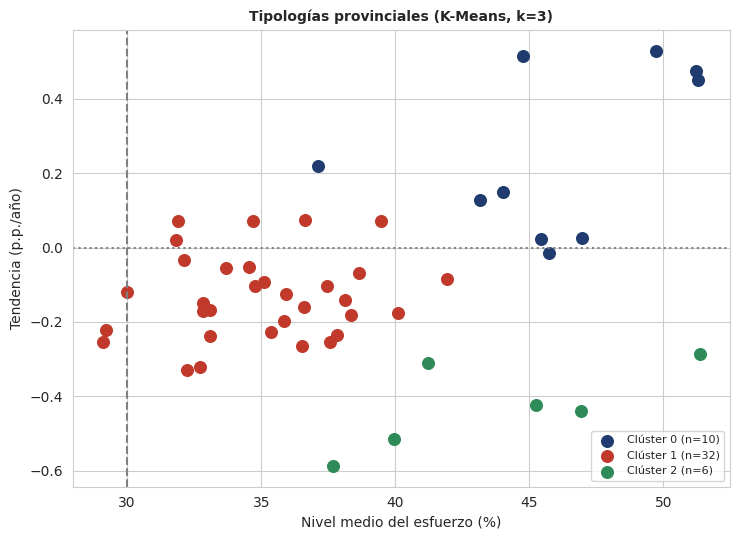

In [17]:
fig,ax=plt.subplots(figsize=(7.5,5.5))
for c in range(K):
    sub=prof[prof.cluster==c]; ax.scatter(sub.nivel,sub.tendencia,s=70,color=PAL[c],label=f'Clúster {c} (n={len(sub)})')
ax.axvline(30,ls='--',c='gray'); ax.axhline(0,ls=':',c='gray')
ax.set_xlabel('Nivel medio del esfuerzo (%)'); ax.set_ylabel('Tendencia (p.p./año)')
ax.set_title('Tipologías provinciales (K-Means, k=3)',fontweight='bold',fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'Analisis_Fig05_tipologias_KMeans.png',dpi=150,bbox_inches='tight'); display(fig); plt.close(fig)


### **Dimensión poblacional de las tipologías**

Las tipologías no solo difieren en nivel y tendencia del esfuerzo, sino en la **población que abarcan**. Cruzando la partición de K-Means con el padrón de población joven (18-34 años, 2022) se obtiene cuántos jóvenes vive en cada grupo. El resultado es marcadamente asimétrico: el grupo **tensionado al alza**, pese a reunir solo diez provincias, concentra al **50,5 %** de la juventud (4,1 millones), frente al 38,2 % (3,1 millones) del grupo intermedio y el 11,3 % (0,9 millones) del grupo en descenso. Este dato dimensiona la prioridad territorial y se interpreta en el Análisis de Negocio: focalizar en esas diez provincias no es actuar sobre un rincón del mapa, sino llegar a uno de cada dos jóvenes del país.

In [18]:
# Dimensión poblacional de las tipologías: ¿cuántos jóvenes vive en cada grupo?
# Cruza la partición de K-Means (prof.cluster) con el padrón de población joven (pobjov, 2022).
_pob22 = pobjov[pobjov.año==2022][['cpro','pob_18_34']]
_tip = prof.reset_index().merge(_pob22, on='cpro'); _tot = _tip.pob_18_34.sum()
print('Población joven (18-34, padrón 2022) por tipología del esfuerzo:')
for c in sorted(prof.cluster.unique(), key=lambda c:-prof[prof.cluster==c].tendencia.mean()):
    sub=_tip[_tip.cluster==c]; pp=sub.pob_18_34.sum()
    et=('tensionada al alza' if prof[prof.cluster==c].tendencia.mean()>0
        else ('alta a la baja' if prof[prof.cluster==c].nivel.mean()>40 else 'intermedia'))
    print(f'  Clúster {c} ({et}, n={len(sub)} prov.): {pp:,.0f} jóvenes = {pp/_tot*100:.1f}%')
print(f'  Total: {_tot:,.0f} jóvenes de 18-34 años (2022)')

Población joven (18-34, padrón 2022) por tipología del esfuerzo:
  Clúster 0 (tensionada al alza, n=10 prov.): 4,138,251 jóvenes = 50.5%
  Clúster 1 (intermedia, n=32 prov.): 3,126,666 jóvenes = 38.2%
  Clúster 2 (alta a la baja, n=6 prov.): 925,645 jóvenes = 11.3%
  Total: 8,190,562 jóvenes de 18-34 años (2022)


La caracterización de las tipologías se completa con el detalle por provincia: para cada grupo se listan sus territorios y su nivel de esfuerzo en 2024, junto con la tendencia del periodo. Esta desagregación permite ilustrar cada tipología con casos concretos y cifras verificables.

In [19]:
# Caracterización por provincia de cada tipología: esfuerzo 2024 (%) y tendencia (p.p./año).
# Respalda, con una salida reproducible, los casos concretos citados al interpretar las tipologías.
_esf24 = panel[panel.año==2024].set_index('cpro')['tasa_esfuerzo']
_car = prof.copy(); _car['provincia']=prov_names; _car['esf_2024']=_esf24
_et = {c:('tensionada al alza' if _car[_car.cluster==c].tendencia.mean()>0
          else ('alta a la baja' if _car[_car.cluster==c].nivel.mean()>40 else 'intermedia'))
       for c in _car.cluster.unique()}
print('Provincias por tipología — esfuerzo 2024 (%) y tendencia (p.p./año):')
for c in sorted(_car.cluster.unique(), key=lambda c:-_car[_car.cluster==c].tendencia.mean()):
    sub=_car[_car.cluster==c].sort_values('esf_2024', ascending=False)
    print(f'\n— {_et[c]} (n={len(sub)}):')
    for _,r in sub.iterrows():
        print(f'   {r.provincia:<24} esf2024={r.esf_2024:4.1f}%   tend={r.tendencia:+.2f}')

Provincias por tipología — esfuerzo 2024 (%) y tendencia (p.p./año):

— tensionada al alza (n=10):
   Málaga                   esf2024=52.9%   tend=+0.48
   Balears, Illes           esf2024=51.2%   tend=+0.53
   Ceuta                    esf2024=50.3%   tend=+0.45
   Madrid                   esf2024=46.7%   tend=+0.03
   Barcelona                esf2024=44.7%   tend=+0.02
   Melilla                  esf2024=44.6%   tend=+0.51
   Cádiz                    esf2024=44.2%   tend=-0.01
   Santa Cruz de Tenerife   esf2024=42.8%   tend=+0.15
   Palmas, Las              esf2024=41.9%   tend=+0.13
   Valencia/València        esf2024=39.8%   tend=+0.22

— intermedia (n=32):
   Granada                  esf2024=41.1%   tend=-0.09
   Alicante/Alacant         esf2024=39.3%   tend=+0.07
   Cantabria                esf2024=37.8%   tend=-0.07
   Guadalajara              esf2024=37.5%   tend=+0.07
   Badajoz                  esf2024=37.4%   tend=-0.17
   Albacete                 esf2024=37.2%   tend=-0.18

### **Figura 6 — Escenario de la tasa de esfuerzo 2025–2027 (ARIMA)**

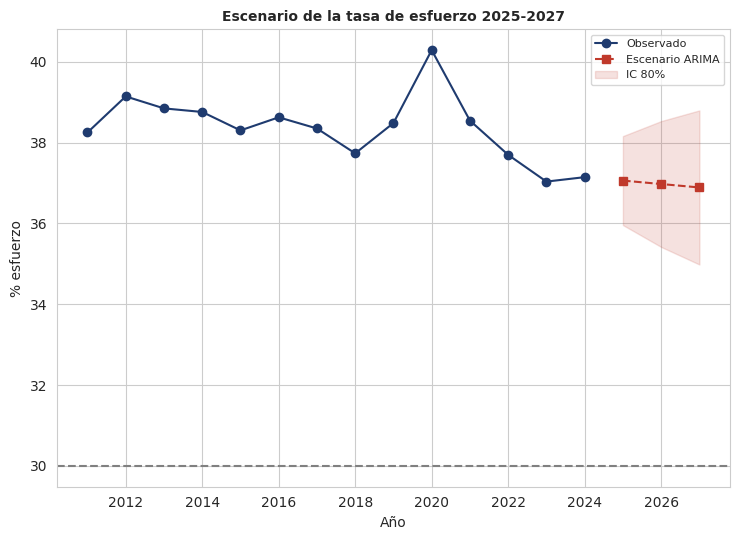

In [20]:
fig,ax=plt.subplots(figsize=(7.5,5.5))
hist=s.astype(float); ax.plot(range(2011,2025),hist.values,marker='o',c=PAL[0],label='Observado')
fy=[2025,2026,2027]; ax.plot(fy,fc.predicted_mean,marker='s',ls='--',c=PAL[1],label='Escenario ARIMA')
ax.fill_between(fy,ci.values[:,0],ci.values[:,1],color=PAL[1],alpha=.15,label='IC 80%')
ax.axhline(30,ls='--',c='gray'); ax.set_xlabel('Año'); ax.set_ylabel('% esfuerzo')
ax.set_title('Escenario de la tasa de esfuerzo 2025-2027',fontweight='bold',fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'Analisis_Fig06_escenario_2025_2027.png',dpi=150,bbox_inches='tight'); display(fig); plt.close(fig)


La Figura 5 sitúa cada provincia en el plano definido por el nivel medio y la tendencia del esfuerzo, donde se distinguen tres tipologías interpretables. La separación estadística no es máxima —la silueta favorece k = 2 (0,514) sobre k = 3 (0,486)—, pero el margen es muy pequeño (0,03) y se adopta k = 3 por su lectura sustantiva: distingue un grupo de esfuerzo agudo y al alza (Baleares, Barcelona, Madrid), uno intermedio mayoritario y uno de esfuerzo alto pero a la baja. La partición es robusta: concuerda en un 86 % (ARI = 0,86) con un agrupamiento jerárquico independiente. La Figura 6 prolonga la serie nacional del esfuerzo hacia 2025-2027 junto con su intervalo de confianza; la banda proyectada se mantiene por encima del umbral del 30 % en todo el horizonte.

---
## **7. Interpretación de resultados**

In [21]:
# Gradiente por edad (2024) e impacto (último año común 2022)
g=edad[edad.año==2024].groupby('banda_edad')['tasa_esfuerzo'].mean()
print('Gradiente por edad 2024 (esfuerzo medio):'); print(g.round(1).to_string())
m22=panel[panel.año==2022][['cpro','sobre_30']].merge(pobjov[pobjov.año==2022],on='cpro')
tot=m22.pob_18_34.sum(); aff=m22.loc[m22.sobre_30==1,'pob_18_34'].sum()
print(f'\nImpacto 2022: {aff:,.0f} de {tot:,.0f} jóvenes 18-34 ({aff/tot*100:.1f}%) viven en provincias con esfuerzo >30%.')

Gradiente por edad 2024 (esfuerzo medio):
banda_edad
18-25    71.6
26-35    37.1
36-45    31.2

Impacto 2022: 8,017,646 de 8,190,562 jóvenes 18-34 (97.9%) viven en provincias con esfuerzo >30%.


El último paso traduce los resultados técnicos a conclusiones legibles, siguiendo los tres planos que señala la presentación: diagnóstico, comportamiento y traducción.

**Diagnóstico.** La competición entre modelos deja una lección que va más allá del resultado numérico: en un panel pequeño y con tendencia, el modelo sencillo generaliza mejor que el complejo. Que la regresión Ridge supere a los modelos de árboles (Random Forest y Gradient Boosting) no delata una limitación del análisis, sino un rasgo del problema: el alquiler es persistente y su relación con los determinantes es esencialmente lineal, lo que recuerda que la sofisticación no garantiza precisión. El análisis de robustez matiza esa capacidad explicativa: buena parte del nivel del alquiler es identidad de cada provincia, y lo que los determinantes añaden es la dinámica con la que el precio se mueve dentro de cada territorio.

**Comportamiento.** Las variables con mayor peso en el modelo lineal son el volumen de contratos y el salario mínimo, seguidos del paro y de los salarios por edad, lo que apunta a una asociación del alquiler con la actividad del mercado y el contexto económico general antes que con un único factor. Pero los residuos matizan ese relato. Los mercados que se desvían al alza de sus fundamentales son turísticos y costeros; una hipótesis razonable, que este trabajo no puede confirmar al no incorporar variables de turismo, es que en ellos el precio pueda estar asociado a una demanda externa que el salario residente no explica por sí solo. En cualquier caso, el patrón confirma que el problema no es homogéneo en el territorio. Las tipologías del agrupamiento confirman esa heterogeneidad y ordenan las provincias por intensidad y dirección del esfuerzo, mientras que el escenario temporal anticipa que, sin cambios, la carga seguirá por encima del 30 % en los próximos años.

**Traducción al negocio.** El diagnóstico es contundente: la inasequibilidad es casi universal (el 95,8 % de las observaciones supera el 30 % y, en 2022, el 97,9 % de los jóvenes de 18 a 34 años residía en provincias donde el KPI provincial superaba el umbral del 30 %, cifra que mide la exposición territorial al problema y no el número de jóvenes arrendatarios afectados individualmente) y profundamente desigual por edad, pues la banda de 18 a 25 años destina en torno al 72 % de su salario al alquiler, frente al 31 % de la de 36 a 45. Estos resultados delimitan el terreno del Análisis de Negocio: dónde actuar (las tipologías y los mercados recalentados), sobre quién (la juventud más temprana) y con qué urgencia (un escenario que no mejora por sí solo).

**Del dato al negocio.** Cada salida de este análisis alimenta directamente una decisión del Análisis de Negocio, y esa es su utilidad: la **tasa de esfuerzo** y su **escenario ARIMA** (Figura 6) dimensionan la magnitud y la urgencia del problema; las **tipologías del K-Means** (Figura 5) señalan *dónde* actuar, agrupando las provincias por intensidad y dirección del esfuerzo; los **determinantes de la inferencia** (Tabla 4) indican *sobre qué palancas* tiene sentido intervenir (volumen de contratos y salario mínimo a la cabeza); y los **residuos del modelo** (Tabla 6) localizan los **mercados recalentados**, donde el precio se desvía de sus fundamentales. Esa correspondencia salida-decisión es el puente que se desarrolla, ya en términos de recomendaciones, en el Análisis de Negocio.

---
## **Fuentes**

La bibliografía completa, normalizada en APA 7.ª y citada en el texto (autor y año), se recoge de forma unificada en la memoria. A modo de referencia, las fuentes empleadas en este análisis son las siguientes. **Métodos:** Hoerl y Kennard (1970), Breiman (2001), Friedman (2001), MacQueen (1967), Lloyd (1982), Box y Jenkins (1976), Dickey y Fuller (1979) y Rosen (1974). **Datos** (heredados de la Ingeniería del Dato): SERPAVI (Ministerio de Vivienda y Agenda Urbana), AEAT, y las estadísticas del INE (Encuesta de Población Activa, Índice de Precios de Consumo y padrón de población), junto con el Salario Mínimo Interprofesional (Ministerio de Trabajo).